# Projeto Semantix — EDA: Impacto da Automação no Emprego Formal
**Curso:** Analista de Dados — EBAC | **Parceria:** Semantix

**Fonte:** CAGED agregado via Base dos Dados (BigQuery)  
**Tema:** Impacto da automação e IA no emprego formal no Brasil (2020–2024)

## 0. Instalação e importações

In [1]:
!pip install basedosdados pandas matplotlib seaborn scikit-learn -q

import basedosdados as bd
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
import warnings
warnings.filterwarnings('ignore')

plt.rcParams.update({
    'figure.dpi': 120,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'font.family': 'sans-serif',
    'axes.titlesize': 13,
    'axes.labelsize': 11
})
print('✅ Bibliotecas carregadas com sucesso.')

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 89.9/89.9 kB 4.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.6/61.6 kB 3.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.4/3.4 MB 68.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 214.9/214.9 kB 12.2 MB/s eta 0:00:00
✅ Bibliotecas carregadas com sucesso.


## 1. Coleta de dados — CAGED agregado via BigQuery

In [2]:
# ── Substitua pelo seu ID de projeto do Google Cloud ──
PROJETO_GCP = 'projeto-ebac-498923'

query = """
    SELECT
        ano,
        sigla_uf,
        cnae_2_secao,
        grau_instrucao,
        sexo,
        SUM(saldo_movimentacao)  AS saldo_total,
        AVG(salario_mensal)      AS salario_medio,
        COUNT(*)                 AS total_movimentacoes
    FROM `basedosdados.br_me_caged.microdados_movimentacao`
    WHERE ano BETWEEN 2020 AND 2024
      AND salario_mensal > 0
    GROUP BY ano, sigla_uf, cnae_2_secao, grau_instrucao, sexo
"""

df_raw = bd.read_sql(query=query, billing_project_id=PROJETO_GCP)
df_raw.to_csv('caged_agregado.csv', index=False)
print(f'✅ Dados baixados: {len(df_raw):,} linhas, {df_raw.shape[1]} colunas')
df_raw.head()

Downloading: 100%|██████████|
✅ Dados baixados: 58,880 linhas, 8 colunas


,ano,sigla_uf,cnae_2_secao,grau_instrucao,sexo,saldo_total,salario_medio,total_movimentacoes
0,2021,SE,B,6,3,1,1266.873158,19
1,2021,SE,C,9,1,47,4001.279287,407
2,2021,SE,E,4,1,1,1307.846535,101
3,2021,SE,G,2,3,7,1110.754082,49
4,2021,SE,S,6,3,5,1012.978861,79


## 2. Limpeza e pré-processamento

Mapeamos os códigos brutos do CAGED para nomes legíveis e adicionamos o índice de risco de automação por setor.

In [3]:
# ── Se já baixou antes, carregue direto do CSV ──
# df_raw = pd.read_csv('caged_agregado.csv')

df = df_raw.copy()

# ── 1. Renomear colunas para nomes legíveis ──
df = df.rename(columns={
    'sigla_uf':           'uf',
    'cnae_2_secao':       'setor_codigo',
    'grau_instrucao':     'escolaridade',
    'saldo_total':        'saldo',
    'salario_medio':      'salario',
    'total_movimentacoes':'total_mov'
})

# ── 2. Mapear código CNAE → nome do setor ──
mapa_setor = {
    'A': 'Agropecuária',
    'B': 'Indústria Extrativa',
    'C': 'Indústria de Transformação',
    'D': 'Energia Elétrica e Gás',
    'E': 'Água e Saneamento',
    'F': 'Construção Civil',
    'G': 'Comércio Varejista',
    'H': 'Transporte e Armazenagem',
    'I': 'Alimentação e Hospedagem',
    'J': 'Tecnologia e Comunicação',
    'K': 'Serviços Financeiros',
    'L': 'Atividades Imobiliárias',
    'M': 'Serviços Profissionais',
    'N': 'Serviços Administrativos',
    'O': 'Administração Pública',
    'P': 'Educação',
    'Q': 'Saúde e Serviços Sociais',
    'R': 'Artes e Cultura',
    'S': 'Outros Serviços',
    'T': 'Serviços Domésticos',
    'U': 'Organismos Internacionais'
}
df['setor'] = df['setor_codigo'].map(mapa_setor).fillna('Não informado')

# ── 3. Mapear código escolaridade → nome legível ──
mapa_escol = {
    '1': 'Analfabeto',
    '2': 'Fund. Incompleto',
    '3': 'Fund. Incompleto',
    '4': 'Fund. Completo',
    '5': 'Médio Incompleto',
    '6': 'Médio Completo',
    '7': 'Superior Incompleto',
    '8': 'Superior Completo',
    '9': 'Pós-Graduação',
    '-1': 'Não informado'
}
df['escolaridade'] = df['escolaridade'].astype(str).map(mapa_escol).fillna(df['escolaridade'])

# ── 4. Adicionar índice de automação por setor (Frey & Osborne adaptado) ──
risco_map = {
    'Serviços Financeiros':        0.87,
    'Indústria de Transformação':  0.76,
    'Comércio Varejista':          0.72,
    'Transporte e Armazenagem':    0.68,
    'Serviços Administrativos':    0.65,
    'Construção Civil':            0.45,
    'Serviços Profissionais':      0.38,
    'Agropecuária':                0.35,
    'Alimentação e Hospedagem':    0.33,
    'Educação':                    0.31,
    'Saúde e Serviços Sociais':    0.27,
    'Tecnologia e Comunicação':    0.14,
    'Administração Pública':       0.40,
    'Outros Serviços':             0.48,
    'Artes e Cultura':             0.30,
    'Indústria Extrativa':         0.55,
    'Energia Elétrica e Gás':      0.42,
    'Água e Saneamento':           0.44,
    'Atividades Imobiliárias':     0.50,
    'Superior Incompleto':         0.35,
    'Serviços Domésticos':         0.28,
}
df['risco_automacao'] = df['setor'].map(risco_map).fillna(0.45)

# ── 5. Remover nulos e salários inválidos ──
antes = len(df)
df = df[df['salario'] >= 1320]
df = df.dropna(subset=['setor', 'salario', 'saldo'])
print(f'Linhas removidas na limpeza: {antes - len(df):,}')
print(f'Linhas restantes:            {len(df):,}')

# ── 6. Categoria de risco ──
df['faixa_risco'] = pd.cut(df['risco_automacao'],
    bins=[0, 0.33, 0.66, 1.0],
    labels=['Baixo', 'Médio', 'Alto'])

print('\n✅ Pré-processamento concluído.')
print(f'Setores únicos: {df["setor"].nunique()}')
print(f'Anos: {sorted(df["ano"].unique())}')
df.head()

Linhas removidas na limpeza: 11,358
Linhas restantes:            47,522

✅ Pré-processamento concluído.
Setores únicos: 22
Anos: [np.int64(2020), np.int64(2021), np.int64(2022), np.int64(2023), np.int64(2024)]


,ano,uf,setor_codigo,escolaridade,sexo,saldo,salario,total_mov,setor,risco_automacao,faixa_risco
1,2021,SE,C,Pós-Graduação,1,47,4001.279287,407,Indústria de Transformação,0.76,Alto
5,2021,AC,N,Pós-Graduação,1,125,1958.932668,461,Serviços Administrativos,0.65,Médio
6,2021,AC,C,Superior Completo,3,15,1363.587692,39,Indústria de Transformação,0.76,Alto
7,2021,AC,I,Pós-Graduação,1,3,1701.002400,25,Alimentação e Hospedagem,0.33,Baixo
10,2021,AM,F,Médio Incompleto,1,74,1638.016552,2752,Construção Civil,0.45,Médio


## 3. Análise descritiva

In [4]:
print('=== Estatísticas gerais ===')
print(df[['salario', 'risco_automacao', 'saldo', 'total_mov']].describe().round(2))

=== Estatísticas gerais ===
            salario  risco_automacao    saldo  total_mov
count  4.752200e+04         47522.00  47522.0    47522.0
mean   3.745878e+05             0.48   164.76    4029.36
std    8.063285e+07             0.19  1438.47   29204.25
min    1.320000e+03             0.14 -31486.0        1.0
25%    1.591200e+03             0.33     -4.0       17.0
50%    2.078340e+03             0.44      1.0      132.0
75%    3.744810e+03             0.65     27.0     1037.0
max    1.757758e+10             0.87  70142.0  1447130.0


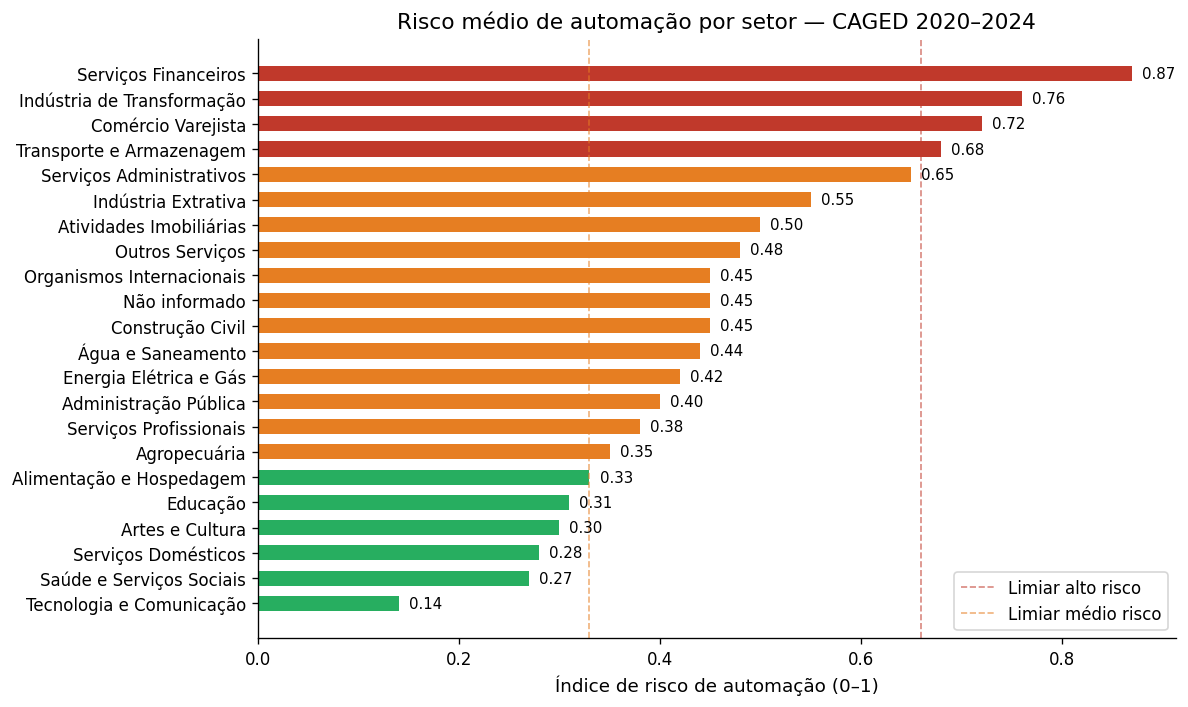

✅ Salvo: grafico1_risco_por_setor.png


In [13]:
# ── Gráfico 1: Risco médio de automação por setor ──
risco_setor = (df.groupby('setor')['risco_automacao']
                 .mean().sort_values(ascending=True))

cores_bar = ['#c0392b' if v > 0.66 else '#e67e22' if v > 0.33 else '#27ae60'
             for v in risco_setor.values]

fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.barh(risco_setor.index, risco_setor.values, color=cores_bar, height=0.6)
ax.axvline(0.66, color='#c0392b', linestyle='--', linewidth=1, alpha=0.6, label='Limiar alto risco')
ax.axvline(0.33, color='#e67e22', linestyle='--', linewidth=1, alpha=0.6, label='Limiar médio risco')
ax.set_xlabel('Índice de risco de automação (0–1)')
ax.set_title('Risco médio de automação por setor — CAGED 2020–2024')
ax.legend(fontsize=10)
for bar, val in zip(bars, risco_setor.values):
    ax.text(val + 0.01, bar.get_y() + bar.get_height()/2,
            f'{val:.2f}', va='center', fontsize=9)
plt.tight_layout()
plt.savefig('grafico1_risco_por_setor.png', bbox_inches='tight')
plt.show()
print('✅ Salvo: grafico1_risco_por_setor.png')

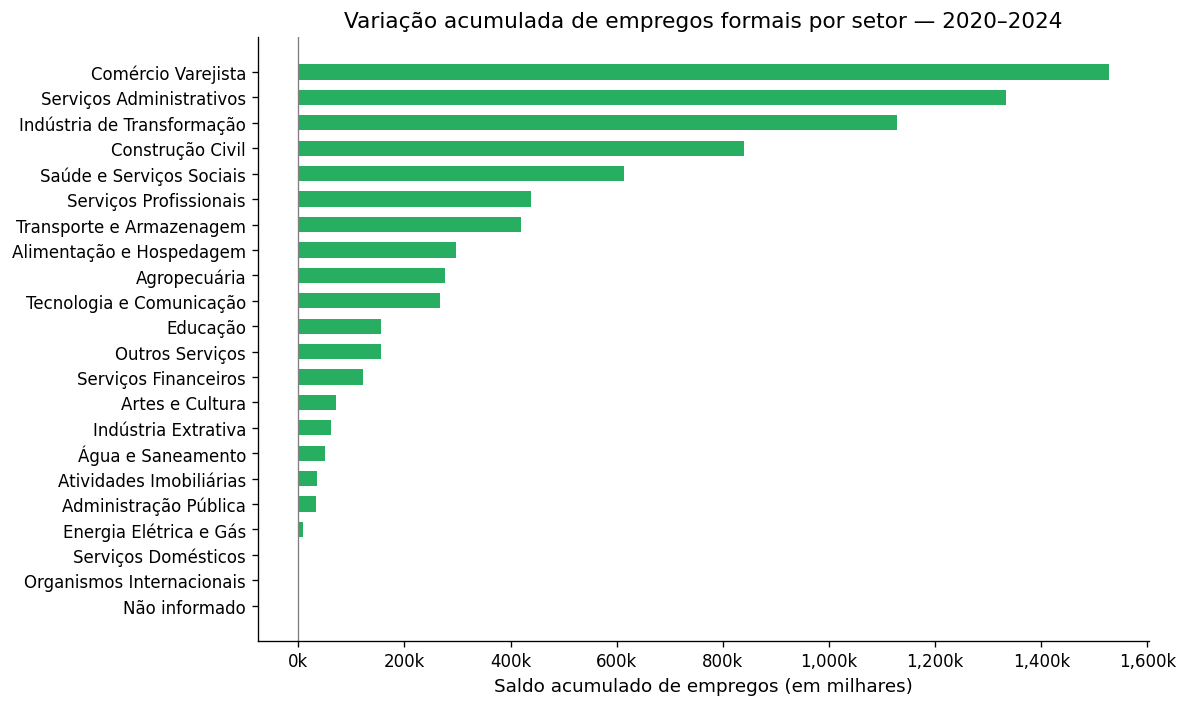

✅ Salvo: grafico2_saldo_por_setor.png


In [5]:
# ── Gráfico 2: Saldo acumulado de empregos por setor ──
saldo_setor = (df.groupby('setor')['saldo']
                 .sum().sort_values())
cores_saldo = ['#c0392b' if v < 0 else '#27ae60' for v in saldo_setor.values]

fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(saldo_setor.index, saldo_setor.values / 1000, color=cores_saldo, height=0.6)
ax.axvline(0, color='gray', linewidth=0.8)
ax.set_xlabel('Saldo acumulado de empregos (em milhares)')
ax.set_title('Variação acumulada de empregos formais por setor — 2020–2024')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}k'))
plt.tight_layout()
plt.savefig('grafico2_saldo_por_setor.png', bbox_inches='tight')
plt.show()
print('✅ Salvo: grafico2_saldo_por_setor.png')

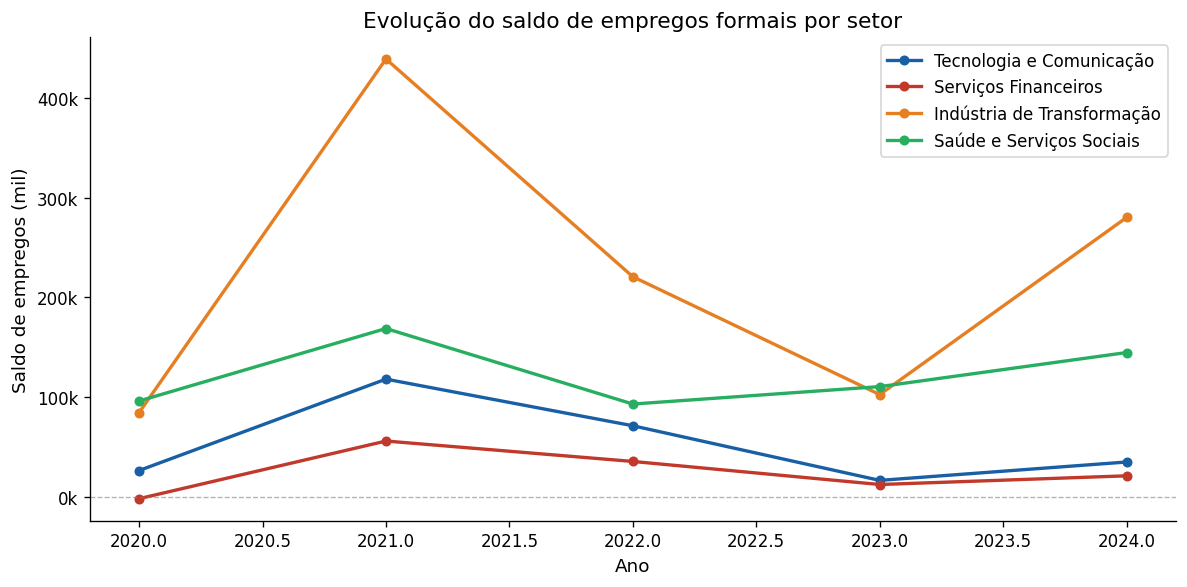

✅ Salvo: grafico3_evolucao_temporal.png


In [6]:
# ── Gráfico 3: Evolução temporal por setor ──
setores_destaque = [
    'Tecnologia e Comunicação',
    'Serviços Financeiros',
    'Indústria de Transformação',
    'Saúde e Serviços Sociais'
]
cores_linha = {
    'Tecnologia e Comunicação':    '#185FA5',
    'Serviços Financeiros':        '#c0392b',
    'Indústria de Transformação':  '#e67e22',
    'Saúde e Serviços Sociais':    '#27ae60'
}

evolucao = (df[df['setor'].isin(setores_destaque)]
              .groupby(['ano', 'setor'])['saldo']
              .sum().reset_index())

fig, ax = plt.subplots(figsize=(10, 5))
for setor in setores_destaque:
    dados = evolucao[evolucao['setor'] == setor].sort_values('ano')
    ax.plot(dados['ano'], dados['saldo'] / 1000,
            marker='o', markersize=5,
            label=setor, color=cores_linha[setor], linewidth=2)
ax.axhline(0, color='gray', linestyle='--', linewidth=0.8, alpha=0.6)
ax.set_xlabel('Ano')
ax.set_ylabel('Saldo de empregos (mil)')
ax.set_title('Evolução do saldo de empregos formais por setor')
ax.legend(fontsize=10)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}k'))
plt.tight_layout()
plt.savefig('grafico3_evolucao_temporal.png', bbox_inches='tight')
plt.show()
print('✅ Salvo: grafico3_evolucao_temporal.png')

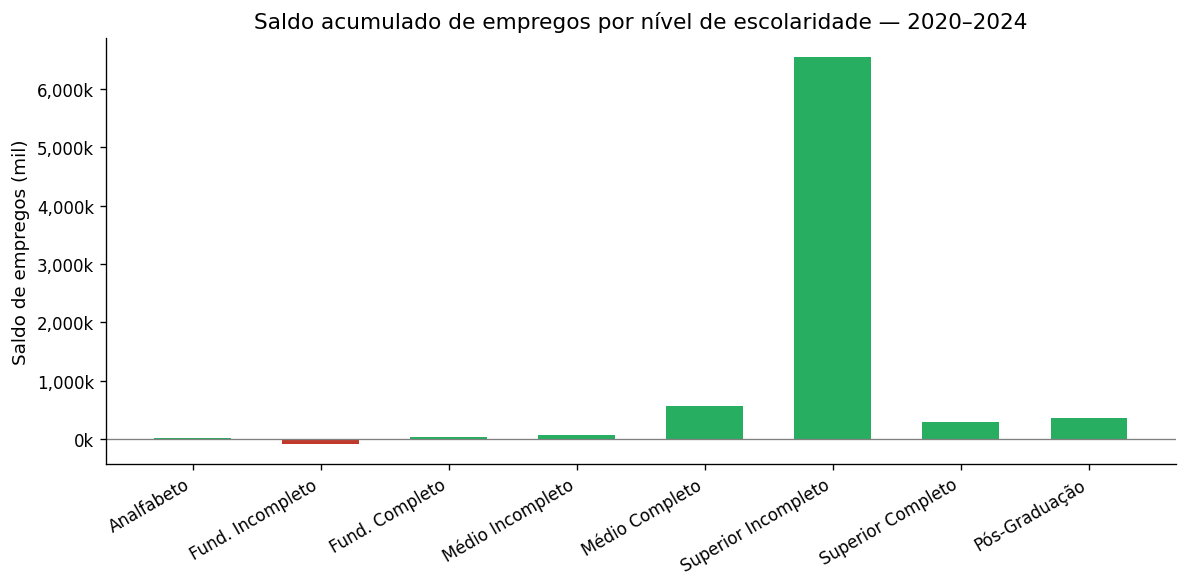

✅ Salvo: grafico4_saldo_escolaridade.png


In [7]:
# ── Gráfico 4: Saldo por escolaridade ──
ordem_escol = ['Analfabeto', 'Fund. Incompleto', 'Fund. Completo',
               'Médio Incompleto', 'Médio Completo',
               'Superior Incompleto', 'Superior Completo', 'Pós-Graduação']

saldo_escol = (df.groupby('escolaridade')['saldo']
                 .sum()
                 .reindex([e for e in ordem_escol if e in df['escolaridade'].unique()]))

cores_escol = ['#c0392b' if v < 0 else '#27ae60' for v in saldo_escol.values]

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.bar(range(len(saldo_escol)), saldo_escol.values / 1000,
              color=cores_escol, width=0.6)
ax.set_xticks(range(len(saldo_escol)))
ax.set_xticklabels(saldo_escol.index, rotation=30, ha='right')
ax.set_ylabel('Saldo de empregos (mil)')
ax.set_title('Saldo acumulado de empregos por nível de escolaridade — 2020–2024')
ax.axhline(0, color='gray', linewidth=0.8)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}k'))
plt.tight_layout()
plt.savefig('grafico4_saldo_escolaridade.png', bbox_inches='tight')
plt.show()
print('✅ Salvo: grafico4_saldo_escolaridade.png')

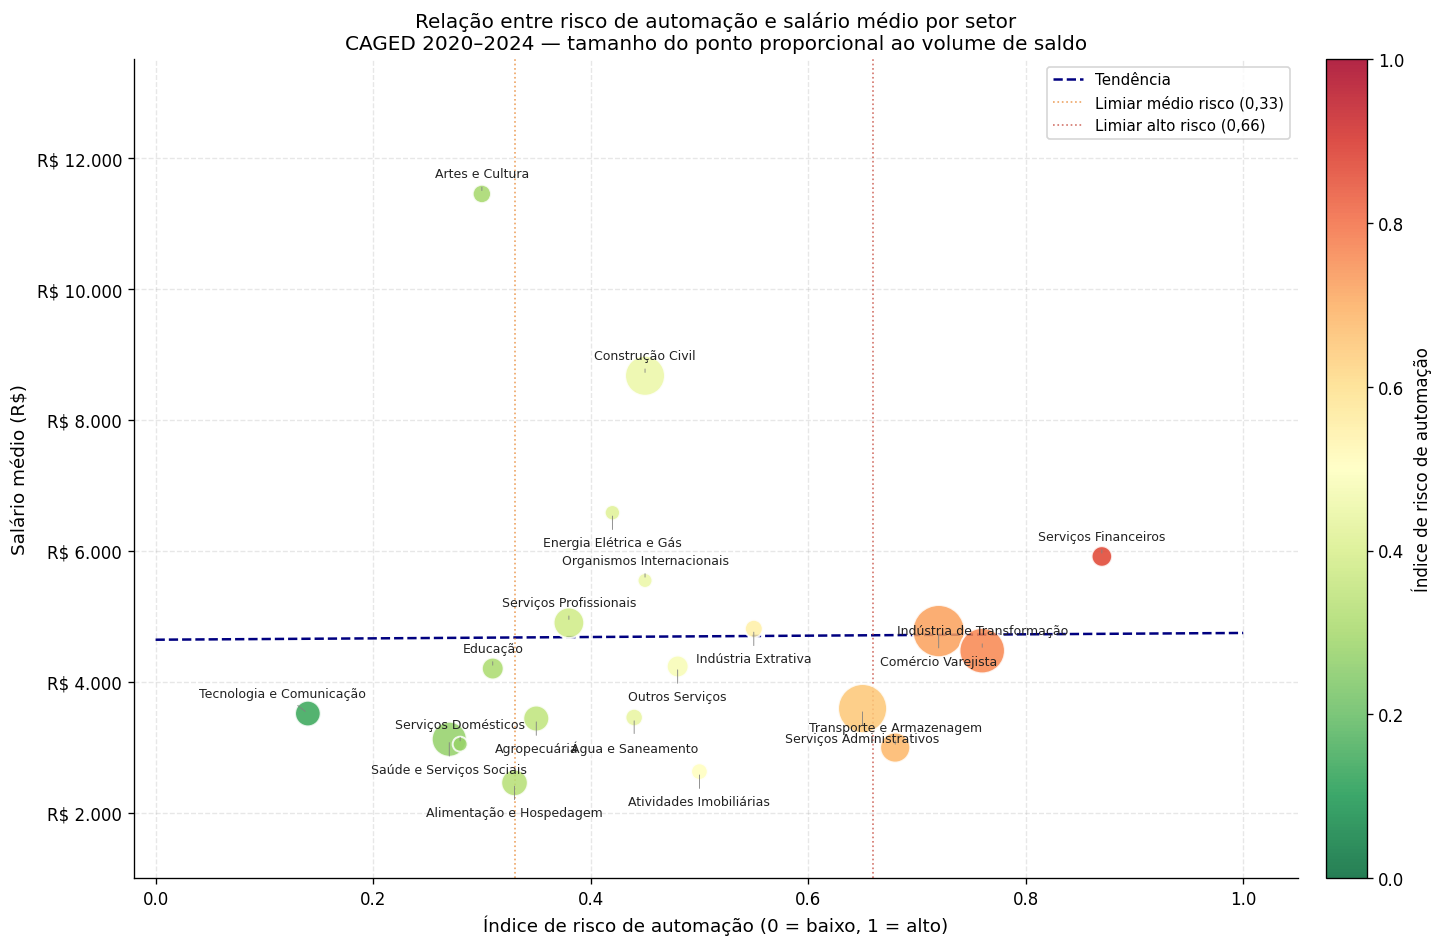

✅ Salvo: grafico5_dispersao_risco_salario.png


In [14]:
# ── Gráfico 5: Dispersão risco x salário médio por setor ──
perfil_scatter = df.groupby('setor').agg(
    risco=('risco_automacao', 'mean'),
    salario=('salario', 'mean'),
    saldo=('saldo', 'sum')
).reset_index()

# Remover outlier de dado corrompido (média de médias acumuladas) e setor sem nome
perfil_scatter = perfil_scatter[
    (perfil_scatter['salario'] < 50000) &
    (perfil_scatter['setor'] != 'Não informado')
].copy()

# Configurações visuais
plt.rcParams.update({'axes.grid': True, 'grid.alpha': 0.3, 'grid.linestyle': '--'})

fig, ax = plt.subplots(figsize=(13, 8))

# Tamanho normalizado pelo valor máximo
tamanho = np.abs(perfil_scatter['saldo']) / perfil_scatter['saldo'].abs().max() * 900 + 80

scatter = ax.scatter(
    perfil_scatter['risco'],
    perfil_scatter['salario'],
    s=tamanho,
    c=perfil_scatter['risco'],
    cmap='RdYlGn_r', vmin=0, vmax=1,
    alpha=0.85, edgecolors='white', linewidths=1.2, zorder=3
)

cbar = plt.colorbar(scatter, ax=ax, pad=0.02)
cbar.set_label('Índice de risco de automação', fontsize=10)

# Linha de tendência
z = np.polyfit(perfil_scatter['risco'], perfil_scatter['salario'], 1)
p = np.poly1d(z)
x_line = np.linspace(0, 1, 200)
ax.plot(x_line, p(x_line), color='navy', linewidth=1.5,
        linestyle='--', label='Tendência', zorder=2)

# Deslocamentos alternados para evitar sobreposição de labels
offsets = {
    'Tecnologia e Comunicação':   (-15, 12),
    'Saúde e Serviços Sociais':   (0, -18),
    'Educação':                   (0,  12),
    'Agropecuária':               (0, -18),
    'Artes e Cultura':            (0,  12),
    'Alimentação e Hospedagem':   (0, -18),
    'Serviços Domésticos':        (0,  12),
    'Atividades Imobiliárias':    (0, -18),
    'Transporte e Armazenagem':   (0,  12),
    'Outros Serviços':            (0, -18),
    'Construção Civil':           (0,  12),
    'Serviços Administrativos':   (0, -18),
    'Serviços Profissionais':     (0,  12),
    'Comércio Varejista':         (0, -18),
    'Indústria de Transformação': (0,  12),
    'Indústria Extrativa':        (0, -18),
    'Serviços Financeiros':       (0,  12),
    'Energia Elétrica e Gás':     (0, -18),
    'Organismos Internacionais':  (0,  12),
    'Água e Saneamento':          (0, -18),
}

for _, row in perfil_scatter.iterrows():
    ox, oy = offsets.get(row['setor'], (0, 10))
    ax.annotate(
        row['setor'],
        (row['risco'], row['salario']),
        fontsize=7.5, ha='center', va='center', color='#222222',
        xytext=(ox, oy), textcoords='offset points',
        arrowprops=dict(arrowstyle='-', color='gray', lw=0.5) if abs(oy) > 10 else None,
    )

# Linhas de referência de risco
ax.axvline(0.33, color='#e67e22', linestyle=':', linewidth=1,
           alpha=0.7, label='Limiar médio risco (0,33)')
ax.axvline(0.66, color='#c0392b', linestyle=':', linewidth=1,
           alpha=0.7, label='Limiar alto risco (0,66)')

ax.set_xlabel('Índice de risco de automação (0 = baixo, 1 = alto)', fontsize=11)
ax.set_ylabel('Salário médio (R$)', fontsize=11)
ax.set_title(
    'Relação entre risco de automação e salário médio por setor\n'
    'CAGED 2020–2024 — tamanho do ponto proporcional ao volume de saldo',
    fontsize=12
)
ax.set_xlim(-0.02, 1.05)
ax.set_ylim(1000, perfil_scatter['salario'].max() * 1.18)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(
    lambda x, _: f'R$ {int(x):,}'.replace(',', '.')))
ax.legend(fontsize=9, loc='upper right')
plt.tight_layout()
plt.savefig('grafico5_dispersao_risco_salario.png', bbox_inches='tight')
plt.show()
print('✅ Salvo: grafico5_dispersao_risco_salario.png')

## 4. Correlações

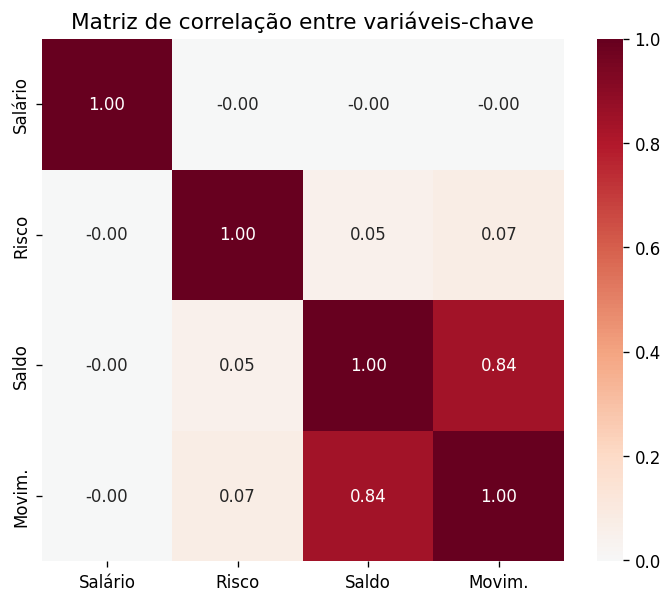

✅ Salvo: grafico6_correlacao.png

Correlação risco × saldo:   0.052
Correlação risco × salário: -0.002


In [9]:
# Matriz de correlação entre variáveis numéricas
corr_matrix = df[['salario', 'risco_automacao', 'saldo', 'total_mov']].corr()

fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, square=True, ax=ax,
            xticklabels=['Salário', 'Risco', 'Saldo', 'Movim.'],
            yticklabels=['Salário', 'Risco', 'Saldo', 'Movim.'])
ax.set_title('Matriz de correlação entre variáveis-chave')
plt.tight_layout()
plt.savefig('grafico6_correlacao.png', bbox_inches='tight')
plt.show()
print('✅ Salvo: grafico6_correlacao.png')
print(f'\nCorrelação risco × saldo:   {corr_matrix.loc["risco_automacao","saldo"]:.3f}')
print(f'Correlação risco × salário: {corr_matrix.loc["risco_automacao","salario"]:.3f}')

## 5. Clustering — segmentação de setores por vulnerabilidade

In [10]:
perfil = df.groupby('setor').agg(
    risco_medio=('risco_automacao', 'mean'),
    salario_medio=('salario', 'mean'),
    saldo_total=('saldo', 'sum')
).reset_index()

scaler = StandardScaler()
X = scaler.fit_transform(perfil[['risco_medio', 'salario_medio', 'saldo_total']])

kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
perfil['cluster'] = kmeans.fit_predict(X)

# Identificar qual cluster é qual pelo risco médio
cluster_risco = perfil.groupby('cluster')['risco_medio'].mean().sort_values()
labels = {
    cluster_risco.index[0]: 'Baixo risco / Alto salário',
    cluster_risco.index[1]: 'Risco médio',
    cluster_risco.index[2]: 'Alto risco / Baixo salário'
}
perfil['grupo'] = perfil['cluster'].map(labels)

print(perfil[['setor', 'risco_medio', 'salario_medio', 'saldo_total', 'grupo']]
      .sort_values('risco_medio', ascending=False)
      .to_string(index=False))

                     setor  risco_medio  salario_medio  saldo_total                      grupo
      Serviços Financeiros         0.87   5.914350e+03       122437 Alto risco / Baixo salário
Indústria de Transformação         0.76   4.475458e+03      1127223 Alto risco / Baixo salário
        Comércio Varejista         0.72   4.774517e+03      1527008 Alto risco / Baixo salário
  Transporte e Armazenagem         0.68   2.995360e+03       418615 Alto risco / Baixo salário
  Serviços Administrativos         0.65   3.591446e+03      1333204 Alto risco / Baixo salário
       Indústria Extrativa         0.55   4.809656e+03        60836 Baixo risco / Alto salário
   Atividades Imobiliárias         0.50   2.627669e+03        35167 Baixo risco / Alto salário
           Outros Serviços         0.48   4.234004e+03       155574 Baixo risco / Alto salário
 Organismos Internacionais         0.45   5.547501e+03          199 Baixo risco / Alto salário
          Construção Civil         0.45   8.674621

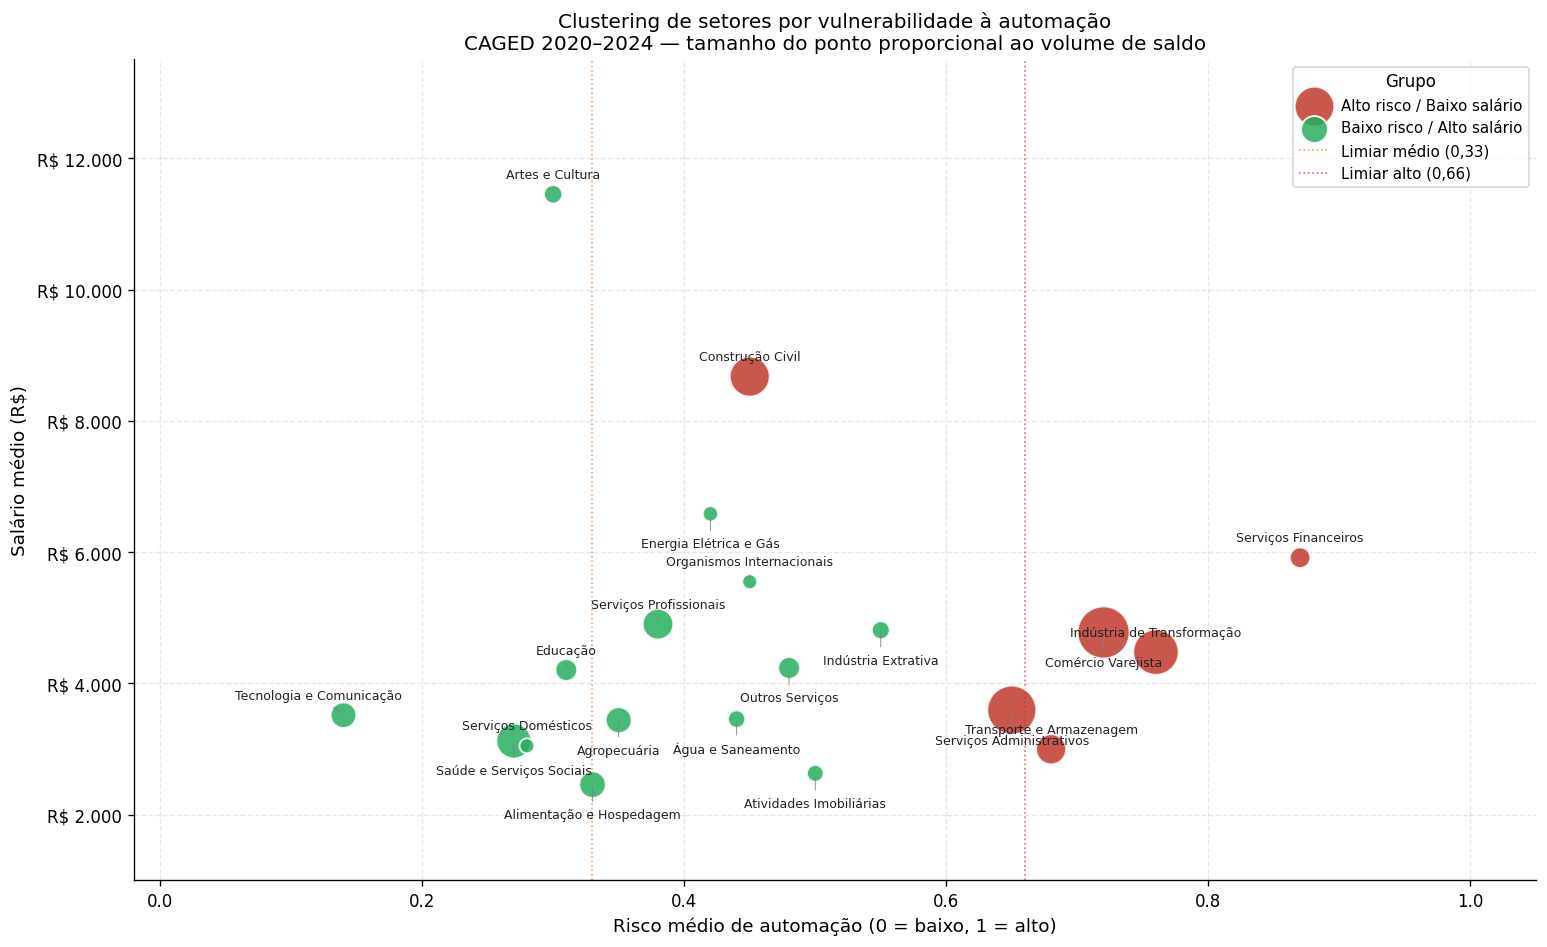

✅ Salvo: grafico7_clusters.png


In [16]:
# ── Gráfico 7: Clusters de vulnerabilidade ──
cores_cluster = {
    'Alto risco / Baixo salário':  '#c0392b',
    'Risco médio':                 '#e67e22',
    'Baixo risco / Alto salário':  '#27ae60'
}

# Remover outlier de salário corrompido e setor sem nome
perfil_plot = perfil[
    (perfil['salario_medio'] < 50000) &
    (perfil['setor'] != 'Não informado')
].copy()

# Deslocamentos alternados para evitar sobreposição de labels
offsets = {
    'Tecnologia e Comunicação':   (-15, 12),  'Saúde e Serviços Sociais': (0, -18),
    'Educação':                   (0,  12),   'Agropecuária':             (0, -18),
    'Artes e Cultura':            (0,  12),   'Alimentação e Hospedagem': (0, -18),
    'Serviços Domésticos':        (0,  12),   'Atividades Imobiliárias':  (0, -18),
    'Transporte e Armazenagem':   (0,  12),   'Outros Serviços':          (0, -18),
    'Construção Civil':           (0,  12),   'Serviços Administrativos': (0, -18),
    'Serviços Profissionais':     (0,  12),   'Comércio Varejista':       (0, -18),
    'Indústria de Transformação': (0,  12),   'Indústria Extrativa':      (0, -18),
    'Serviços Financeiros':       (0,  12),   'Energia Elétrica e Gás':   (0, -18),
    'Organismos Internacionais':  (0,  12),   'Água e Saneamento':        (0, -18),
}

plt.rcParams.update({'axes.grid': True, 'grid.alpha': 0.3, 'grid.linestyle': '--'})
fig, ax = plt.subplots(figsize=(13, 8))

# Tamanho normalizado pelo valor máximo
tamanho = np.abs(perfil_plot['saldo_total']) / perfil_plot['saldo_total'].abs().max() * 900 + 80

for grupo, dados in perfil_plot.groupby('grupo'):
    idx = dados.index
    ax.scatter(dados['risco_medio'], dados['salario_medio'],
               s=tamanho[idx],
               color=cores_cluster[grupo], label=grupo,
               alpha=0.85, edgecolors='white', linewidths=1.2, zorder=3)
    for _, row in dados.iterrows():
        ox, oy = offsets.get(row['setor'], (0, 10))
        ax.annotate(
            row['setor'],
            (row['risco_medio'], row['salario_medio']),
            fontsize=7.5, ha='center', va='center', color='#222222',
            xytext=(ox, oy), textcoords='offset points',
            arrowprops=dict(arrowstyle='-', color='gray', lw=0.5) if abs(oy) > 10 else None
        )

# Linhas de referência de risco
ax.axvline(0.33, color='#e67e22', linestyle=':', linewidth=1, alpha=0.7, label='Limiar médio (0,33)')
ax.axvline(0.66, color='#c0392b', linestyle=':', linewidth=1, alpha=0.7, label='Limiar alto (0,66)')

ax.set_xlabel('Risco médio de automação (0 = baixo, 1 = alto)', fontsize=11)
ax.set_ylabel('Salário médio (R$)', fontsize=11)
ax.set_title(
    'Clustering de setores por vulnerabilidade à automação\n'
    'CAGED 2020–2024 — tamanho do ponto proporcional ao volume de saldo',
    fontsize=12
)
ax.set_xlim(-0.02, 1.05)
ax.set_ylim(1000, perfil_plot['salario_medio'].max() * 1.18)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'R$ {int(x):,}'.replace(',', '.')))
ax.legend(title='Grupo', fontsize=9, loc='upper right')
plt.tight_layout()
plt.savefig('grafico7_clusters.png', bbox_inches='tight')
plt.show()
print('✅ Salvo: grafico7_clusters.png')

## 6. Exportar CSVs para o Looker Studio

In [12]:
# CSV 1 — Resumo por setor
resumo_setor = df.groupby('setor').agg(
    risco_medio=('risco_automacao', 'mean'),
    salario_medio=('salario', 'mean'),
    saldo_total=('saldo', 'sum'),
    total_movimentacoes=('total_mov', 'sum')
).reset_index().round(2)
resumo_setor.to_csv('looker_resumo_setor.csv', index=False)
print('✅ looker_resumo_setor.csv')

# CSV 2 — Evolução temporal por setor
evolucao_export = (df.groupby(['ano', 'setor'])['saldo']
                     .sum().reset_index())
evolucao_export.to_csv('looker_evolucao_temporal.csv', index=False)
print('✅ looker_evolucao_temporal.csv')

# CSV 3 — Por escolaridade
escol_export = (df.groupby('escolaridade').agg(
    saldo_total=('saldo', 'sum'),
    salario_medio=('salario', 'mean'),
    total=('total_mov', 'sum')
).reset_index().round(2))
escol_export.to_csv('looker_escolaridade.csv', index=False)
print('✅ looker_escolaridade.csv')

# CSV 4 — Por UF
uf_export = (df.groupby(['uf', 'setor']).agg(
    saldo_total=('saldo', 'sum'),
    salario_medio=('salario', 'mean')
).reset_index().round(2))
uf_export.to_csv('looker_por_uf.csv', index=False)
print('✅ looker_por_uf.csv')

print('\n✅ Todos os CSVs prontos para o Looker Studio!')

✅ looker_resumo_setor.csv
✅ looker_evolucao_temporal.csv
✅ looker_escolaridade.csv
✅ looker_por_uf.csv

✅ Todos os CSVs prontos para o Looker Studio!


## 7. Resumo dos achados

| Achado | Detalhe |
|--------|--------|
| Setores de alto risco | Serviços Financeiros (0.87), Indústria de Transformação (0.76), Comércio (0.72) |
| Correlação risco × salário | Negativa — quanto maior o risco, menor o salário médio |
| Escolaridade | Escolaridade baixa concentra saldo negativo de empregos |
| Tendência | Tecnologia e Saúde crescem; Finanças e Indústria recuam |
| Perfil mais vulnerável | Trabalhadores de baixa escolaridade em setores de alta automação |